In [2]:
# ML Exercise - Linear Regression

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn.linear_model
import sklearn.metrics
import sklearn.preprocessing
import sklearn.pipeline
import sklearn.datasets

import warnings
warnings.filterwarnings("ignore")

sns.set()

In [11]:
# import dataset
df = pd.read_csv('./data/housing_prices_linear_regression.csv', header=0)

In [12]:
# inspect data
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   property_id             1200 non-null   str    
 1   floor_area_sqft         1200 non-null   int64  
 2   bedrooms                1200 non-null   int64  
 3   bathrooms               1200 non-null   int64  
 4   property_age_years      1200 non-null   int64  
 5   distance_to_city_km     1200 non-null   float64
 6   distance_to_mrt_km      1200 non-null   float64
 7   parking_spots           1200 non-null   int64  
 8   furnishing_score        1200 non-null   int64  
 9   neighborhood_income_rm  1200 non-null   int64  
 10  monthly_maintenance_rm  1200 non-null   float64
 11  sale_price_rm           1200 non-null   float64
dtypes: float64(4), int64(7), str(1)
memory usage: 118.5 KB


,property_id,floor_area_sqft,bedrooms,bathrooms,property_age_years,distance_to_city_km,distance_to_mrt_km,parking_spots,furnishing_score,neighborhood_income_rm,monthly_maintenance_rm,sale_price_rm
0,P0001,3169,6,5,17,10.4,0.78,4,9,5700,917.47,1606561.43
1,P0002,1502,5,5,1,22.0,3.61,4,9,14200,580.40,950267.15
2,P0003,2963,6,5,10,27.0,1.77,4,4,12100,771.56,1450853.20
3,P0004,1958,6,5,2,28.1,2.73,4,2,17600,585.76,1155485.78
4,P0005,3124,6,5,12,27.2,0.32,4,5,5500,887.85,1487122.11


In [13]:
# define X and y
X = df.drop(columns=["property_id", "sale_price_rm"])
y = df["sale_price_rm"]


In [14]:
# split test data set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)


In [15]:
# Fit linear regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 409.3 ,16798. ,19467.49,..., 5292.69, 13.77, -1.47]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['floor_area_sqft','bedrooms','bathrooms',...,'furnishing_score', 'neighborhood_income_rm','monthly_maintenance_rm']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.631e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(10)


In [16]:
# View Coefficient
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df.sort_values("Coefficient", ascending=False))

                  Feature   Coefficient
2               bathrooms  19467.492030
1                bedrooms  16798.001665
6           parking_spots   8017.712565
7        furnishing_score   5292.693106
0         floor_area_sqft    409.295904
8  neighborhood_income_rm     13.770996
9  monthly_maintenance_rm     -1.465803
3      property_age_years  -2717.450383
4     distance_to_city_km  -6133.484963
5      distance_to_mrt_km -10263.941910


In [17]:
# make prediction
y_pred = model.predict(X_test)

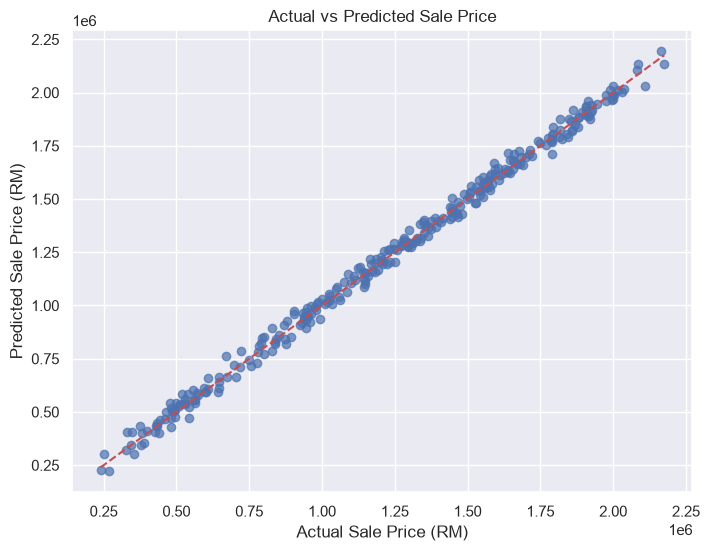

In [21]:
# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Sale Price (RM)')
plt.ylabel('Predicted Sale Price (RM)')
plt.title('Actual vs Predicted Sale Price')
plt.show()


In [22]:
# Evaluate Model Accuracy
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.9957145800906081
MAE: 26251.997527237552
RMSE: 32236.58485150004


In [23]:
# display equation
print("Intercept:", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept: 56305.929686473915
floor_area_sqft: 409.2959037228079
bedrooms: 16798.00166488166
bathrooms: 19467.49202953599
property_age_years: -2717.4503831329757
distance_to_city_km: -6133.484962886636
distance_to_mrt_km: -10263.941910325746
parking_spots: 8017.7125653171015
furnishing_score: 5292.693106335819
neighborhood_income_rm: 13.770996033663323
monthly_maintenance_rm: -1.465802907962825


In [24]:
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

print(
    coef_df.sort_values(
        "Abs_Coefficient",
        ascending=False
    )
)

                  Feature   Coefficient  Abs_Coefficient
2               bathrooms  19467.492030     19467.492030
1                bedrooms  16798.001665     16798.001665
5      distance_to_mrt_km -10263.941910     10263.941910
6           parking_spots   8017.712565      8017.712565
4     distance_to_city_km  -6133.484963      6133.484963
7        furnishing_score   5292.693106      5292.693106
3      property_age_years  -2717.450383      2717.450383
0         floor_area_sqft    409.295904       409.295904
8  neighborhood_income_rm     13.770996        13.770996
9  monthly_maintenance_rm     -1.465803         1.465803
